# V0.4 - Controlled Cybersecurity Attack Scenarios

This notebook evaluates controlled synthetic modifications of real operational DataCo test records. DataCo has no native cybersecurity labels; all `is_attack` values below are experimental ground truth generated before AI inference.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ai.model_utils import load_processed_dataco
from src.config import SECURITY_RESULTS_DIR, V03_MODEL_FILE
from src.pipeline_v04 import run_security_evaluation_v04
from src.security.attack_generator import generate_attack

result = run_security_evaluation_v04()
summary = result['summary']
print('V0.4 status:', summary['status'])
assert summary['status'] == 'PASS'

Simulated tampering: set quantity=1.5 on 75648 (block 1); hashes left stale


Hash mismatch for transaction 75648


V0.4 status: PASS


## 1. Clean processed test data and V0.3 model

In [2]:
bundle = load_processed_dataco()
clean_test = bundle.splits['test']
print('Test records:', len(clean_test.features))
print('V0.3 features:', len(bundle.selected_features))
print('Saved V0.3 model:', Path(V03_MODEL_FILE).exists())
display(clean_test.metadata.head(3))

Test records: 6000
V0.3 features: 43
Saved V0.3 model: True


,row_id,Order Id,Order Item Id,Order Customer Id,Product Card Id,order date (DateOrders),shipping date (DateOrders),Order Status,Delivery Status,Order Region,...,Product Name,Days for shipping (real),Order Item Quantity,Sales,Order Item Total,Type,Market,Shipping Mode,Customer Segment,Department Name
0,22688,48131,120363,4857,191,12/3/2016 14:04,12/5/2016 14:04,COMPLETE,Advance shipping,East Africa,...,Nike Men's Free 5.0+ Running Shoe,2,3,299.970001,272.970001,DEBIT,Africa,Standard Class,Consumer,Footwear
1,47301,55478,138765,5148,627,3/20/2017 20:03,3/24/2017 20:03,PENDING_PAYMENT,Shipping on time,Central America,...,Under Armour Girls' Toddler Spine Surge Runni,4,3,119.970001,118.769997,PAYMENT,LATAM,Standard Class,Corporate,Golf
2,84697,13114,32802,9755,502,7/11/2015 10:04,7/16/2015 10:04,PROCESSING,Late delivery,Western Europe,...,Nike Men's Dri-FIT Victory Golf Polo,5,5,250.000000,237.500000,TRANSFER,Europe,Second Class,Corporate,Golf


## 2. One controlled attack, traceability, and ground truth

In [3]:
attacked_sample, attack_metadata, sample_ground_truth = generate_attack(
    clean_test.metadata,
    attack_type='quantity_manipulation',
    attack_rate=0.01,
    severity='MEDIUM',
    random_state=42,
    experiment_id='notebook_quantity_demo',
)
sample_manifest = attack_metadata['manifest']
print({key: value for key, value in attack_metadata.items() if key not in {'manifest', 'per_attack_type'}})
display(sample_manifest.head())
display(sample_ground_truth[sample_ground_truth['is_attack'].eq(1)].head())

{'stage': 'V0.4', 'experiment_id': 'notebook_quantity_demo', 'attack_mode': 'single', 'attack_types': ['quantity_manipulation'], 'severity': 'MEDIUM', 'configured_attack_rate': 0.01, 'eligible_records': 6000, 'selected_records': 60, 'actual_modified_records': 60, 'attack_rate_achieved': 0.01, 'random_seed': 42, 'record_id_column': 'row_id'}


,experiment_id,record_id,attack_type,attack_severity,original_field,original_dtype,original_value,modified_value,attack_rate,random_seed
0,notebook_quantity_demo,153596,quantity_manipulation,MEDIUM,Order Item Quantity,int64,1.0,0.6,0.01,42
1,notebook_quantity_demo,26936,quantity_manipulation,MEDIUM,Order Item Quantity,int64,3.0,1.8,0.01,42
2,notebook_quantity_demo,81161,quantity_manipulation,MEDIUM,Order Item Quantity,int64,1.0,0.6,0.01,42
3,notebook_quantity_demo,165944,quantity_manipulation,MEDIUM,Order Item Quantity,int64,1.0,1.5,0.01,42
4,notebook_quantity_demo,162211,quantity_manipulation,MEDIUM,Order Item Quantity,int64,4.0,2.4,0.01,42


,record_id,is_attack,attack_type,attack_severity,original_field,original_value,modified_value,attack_rate,random_seed,experiment_id
182,28254,1,quantity_manipulation,MEDIUM,Order Item Quantity,1.0,1.5,0.01,42,notebook_quantity_demo
333,113952,1,quantity_manipulation,MEDIUM,Order Item Quantity,2.0,3.0,0.01,42,notebook_quantity_demo
437,90237,1,quantity_manipulation,MEDIUM,Order Item Quantity,4.0,2.4,0.01,42,notebook_quantity_demo
491,128207,1,quantity_manipulation,MEDIUM,Order Item Quantity,2.0,3.0,0.01,42,notebook_quantity_demo
528,139500,1,quantity_manipulation,MEDIUM,Order Item Quantity,3.0,4.5,0.01,42,notebook_quantity_demo


## 3. Isolation Forest detection and supervised metrics

In [4]:
display(pd.Series(summary['detection'], name='final_label_metrics').drop('confusion_matrix'))
display(pd.Series(summary['visible_attack_detection'], name='visible_attack_metrics').drop('confusion_matrix'))
display(pd.Series(summary['paired_clean_vs_attacked_detection'], name='paired_attack_effect'))
print('Ground truth source:', summary['dataset']['ground_truth_kind'])
print('Detector-visible attacked records:', summary['attack']['detector_visible_modified_records'])

precision                                      0.057756
recall                                             0.35
f1                                              0.09915
pr_auc                                         0.052479
pr_auc_method        trapezoidal_precision_recall_curve
average_precision                              0.053133
roc_auc                                        0.515127
true_positives                                      105
true_negatives                                     3987
false_positives                                    1713
false_negatives                                     195
evaluated_records                                  6000
attacked_records                                    300
Name: final_label_metrics, dtype: object

precision                                      0.035473
recall                                         0.368421
f1                                             0.064715
pr_auc                                         0.032389
pr_auc_method        trapezoidal_precision_recall_curve
average_precision                              0.033259
roc_auc                                        0.523317
true_positives                                       63
true_negatives                                     3987
false_positives                                    1713
false_negatives                                     108
evaluated_records                                  5871
attacked_records                                    171
Name: visible_attack_metrics, dtype: object

attacked_records                 300.000000
already_flagged_before_attack    106.000000
flagged_after_attack             105.000000
newly_detected_after_attack        3.000000
lost_detections_after_attack       4.000000
unchanged_flagged                102.000000
unchanged_not_flagged            191.000000
attack_induced_detection_rate      0.010000
mean_anomaly_score_delta           0.000157
median_anomaly_score_delta         0.000000
Name: paired_attack_effect, dtype: float64

Ground truth source: controlled experimental ground truth
Detector-visible attacked records: 171


## 4. Attack-rate, severity, and attack-type analyses

,attack_type,attack_rate,recall,f1,pr_auc,attack_induced_detection_rate
0,quantity_manipulation,0.01,0.333333,0.021299,0.009642,0.000000
1,quantity_manipulation,0.03,0.327778,0.059089,0.029722,0.022222
2,quantity_manipulation,0.05,0.306667,0.086792,0.049532,0.030000
3,quantity_manipulation,0.10,0.320000,0.158481,0.102207,0.031667
4,value_manipulation,0.01,0.350000,0.022352,0.009812,0.000000
5,value_manipulation,0.03,0.355556,0.063936,0.030068,0.022222
6,value_manipulation,0.05,0.316667,0.089496,0.049971,0.020000
7,value_manipulation,0.10,0.318333,0.157721,0.102770,0.011667
8,shipping_delivery_manipulation,0.01,0.350000,0.022352,0.009799,0.000000
9,shipping_delivery_manipulation,0.03,0.338889,0.061031,0.030002,0.000000


,attack_type,severity,recall,f1,pr_auc,attack_induced_detection_rate
0,quantity_manipulation,LOW,0.306667,0.086792,0.049242,0.010000
1,quantity_manipulation,MEDIUM,0.306667,0.086792,0.049532,0.030000
2,quantity_manipulation,HIGH,0.326667,0.092192,0.052195,0.056667
3,value_manipulation,LOW,0.306667,0.086792,0.049518,0.006667
4,value_manipulation,MEDIUM,0.316667,0.089496,0.049971,0.020000
5,value_manipulation,HIGH,0.326667,0.092192,0.052407,0.030000
6,shipping_delivery_manipulation,LOW,0.303333,0.085890,0.049541,0.000000
7,shipping_delivery_manipulation,MEDIUM,0.303333,0.085890,0.049541,0.000000
8,shipping_delivery_manipulation,HIGH,0.303333,0.085890,0.049541,0.000000
9,transaction_status_manipulation,LOW,0.303333,0.085890,0.049541,0.000000


,attack_type,metrics_scope,detector_visible_modified_records,precision,recall,f1,pr_auc,newly_detected_after_attack
0,quantity_manipulation,attacked_inputs_changed,300,0.050549,0.306667,0.086792,0.049532,9
1,value_manipulation,attacked_inputs_changed,300,0.052112,0.316667,0.089496,0.049971,6
2,shipping_delivery_manipulation,baseline_overlap_only_model_inputs_unchanged,0,0.050027,0.303333,0.085890,0.049541,0
3,transaction_status_manipulation,baseline_overlap_only_model_inputs_unchanged,0,0.050027,0.303333,0.085890,0.049541,0
4,timestamp_manipulation,attacked_inputs_changed,300,0.048982,0.296667,0.084081,0.049732,8
5,geographic_route_manipulation,baseline_overlap_only_model_inputs_unchanged,0,0.050027,0.303333,0.085890,0.049541,0
6,transaction_record_tampering,attacked_inputs_changed,300,0.050027,0.303333,0.085890,0.049730,5


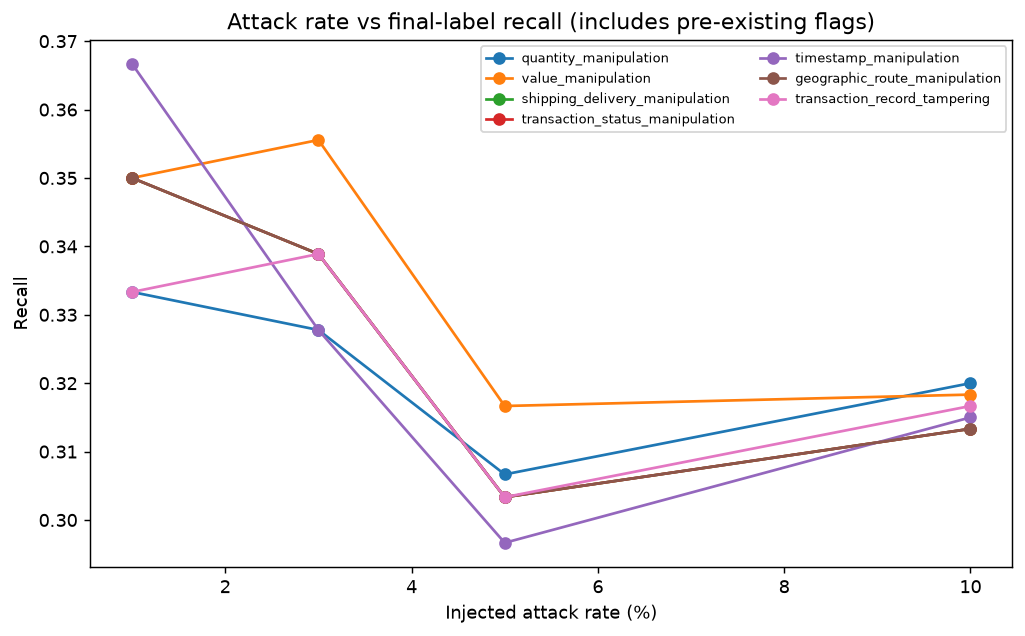

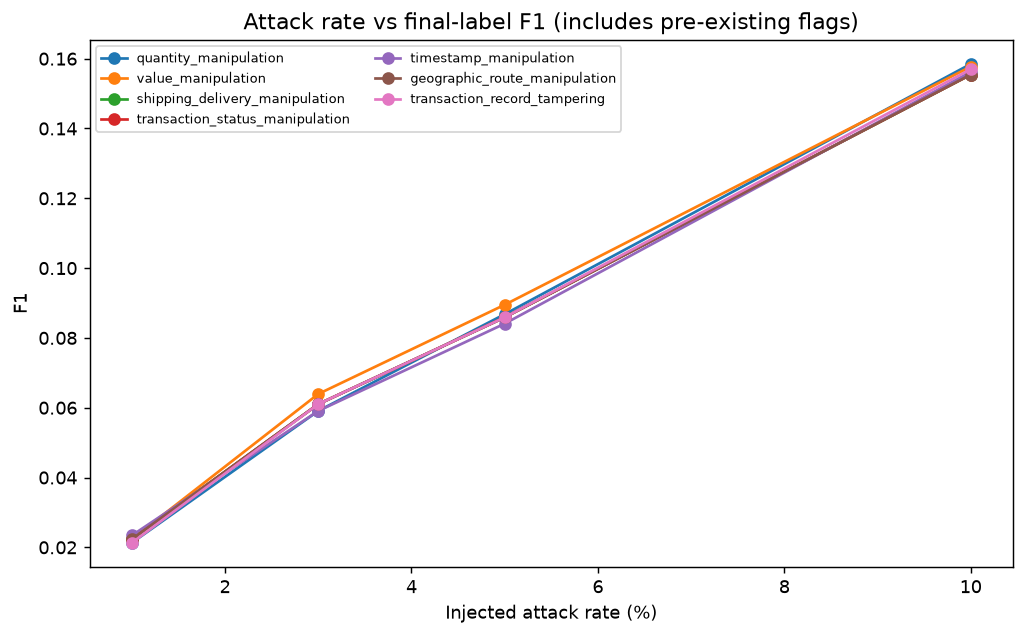

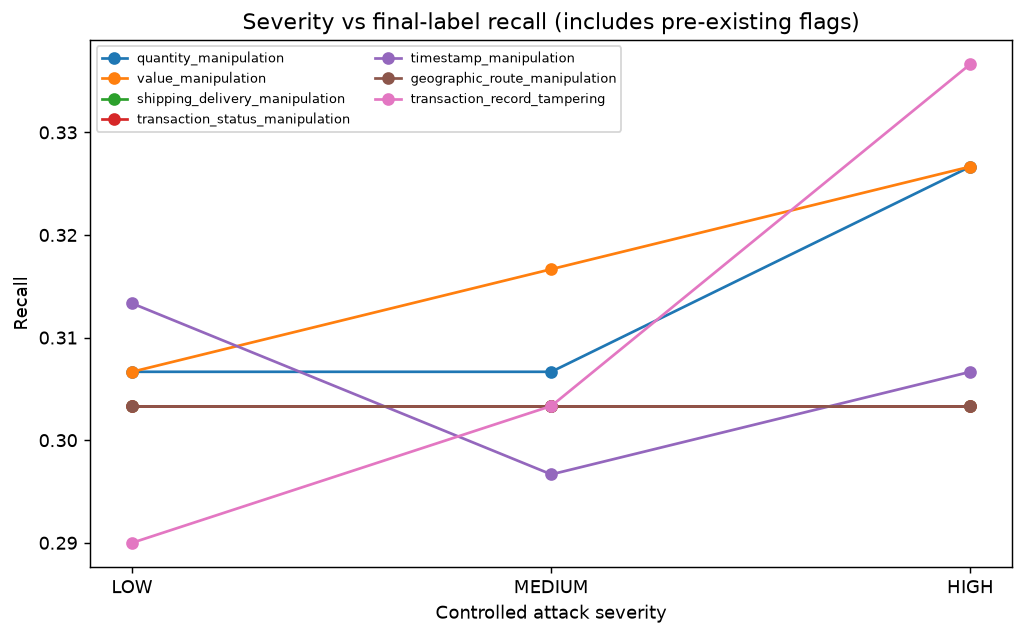

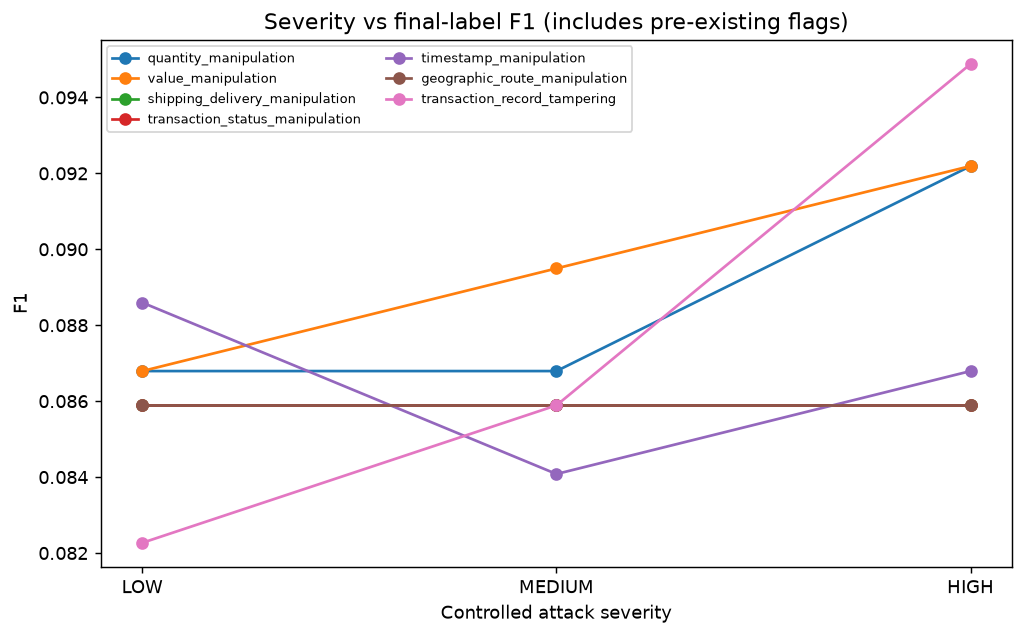

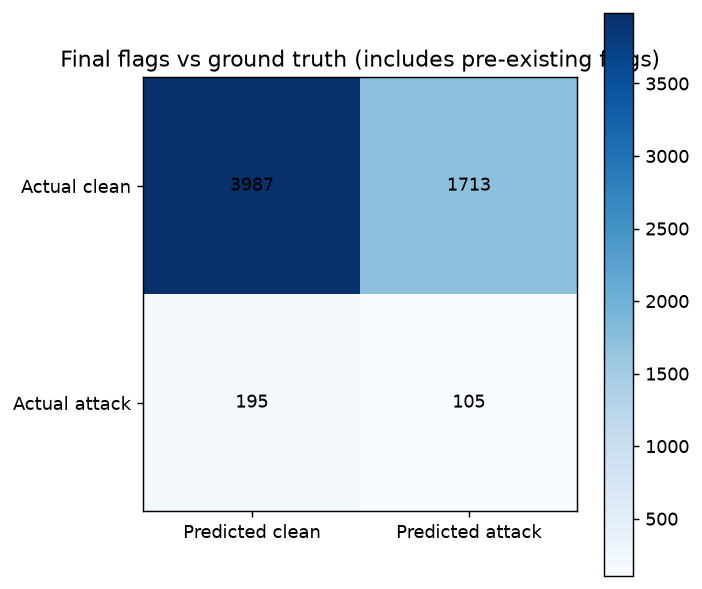

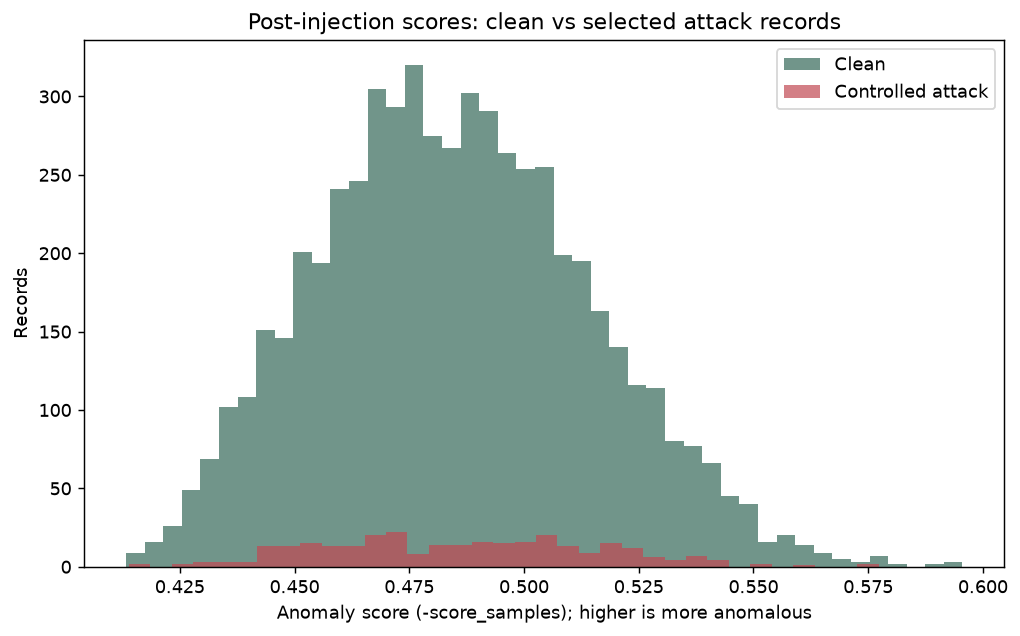

In [5]:
display(result['attack_rate_analysis'][['attack_type', 'attack_rate', 'recall', 'f1', 'pr_auc', 'attack_induced_detection_rate']])
display(result['severity_analysis'][['attack_type', 'severity', 'recall', 'f1', 'pr_auc', 'attack_induced_detection_rate']])
display(result['attack_type_analysis'][['attack_type', 'metrics_scope', 'detector_visible_modified_records', 'precision', 'recall', 'f1', 'pr_auc', 'newly_detected_after_attack']])
for figure_path in result['figure_paths']:
    display(Image(filename=str(figure_path)))

## 5. Blockchain integrity and combined security signals

In [6]:
blockchain = summary['blockchain']
print('CHAIN VALID before tampering =', blockchain['clean_chain_verification'])
print('CHAIN VALID after tampering  =', blockchain['tampered_chain_verification'])
print('Integrity failure detected   =', blockchain['integrity_failure_detected'])
display(pd.Series(result['combined_security'], name='combined_security_report'))
assert blockchain['clean_chain_verification'] is True
assert blockchain['tampered_chain_verification'] is False

CHAIN VALID before tampering = True
CHAIN VALID after tampering  = False
Integrity failure detected   = True


ai_detected_anomaly                           False
blockchain_integrity_valid                    False
record_id                                    153596
transaction_id                                75648
attack_type                   quantity_manipulation
Name: combined_security_report, dtype: object

## 6. Saved results and final summary

In [7]:
required_outputs = [
    'security_summary.json', 'attack_rate_analysis.csv',
    'severity_analysis.csv', 'attack_type_analysis.csv',
    'confusion_matrix.csv', 'leakage_audit.json',
]
for name in required_outputs:
    path = Path(SECURITY_RESULTS_DIR) / name
    print(f'{name}:', 'PASS' if path.exists() else 'FAIL')
    assert path.exists()
print('Leakage audit:', summary['leakage_audit']['status'])
print('Reproducibility:', summary['reproducibility']['status'])
print('Figures:', len(result['figure_paths']))
print('Final status:', summary['status'])
assert summary['leakage_audit']['status'] == 'PASS'
assert summary['reproducibility']['status'] == 'PASS'
assert len(result['figure_paths']) == 6

security_summary.json: PASS
attack_rate_analysis.csv: PASS
severity_analysis.csv: PASS
attack_type_analysis.csv: PASS
confusion_matrix.csv: PASS
leakage_audit.json: PASS
Leakage audit: PASS
Reproducibility: PASS
Figures: 6
Final status: PASS
